Akshat

# Pittsburgh Ward Foreclosure Affordability Analysis

## Final Project Notebook

# 1. Introduction

In this project, we analyze housing stability across Pittsburgh neighborhoods using foreclosure data. Our goal is to determine which wards in Pittsburgh are the most "affordable" and financially stable based on foreclosure activity.

We define affordability not only as the number of foreclosure cases in each ward but also the financial severity of those foreclosures (measured by monetary amounts involved).

### Research Question:

Which Pittsburgh ward shows the highest housing affordability and stability based on foreclosure data?

---

# 2. Dataset Description

We use a foreclosure dataset from the Western Pennsylvania Regional Data Center (WPRDC).

### Columns:

* `_id`: Unique identifier
* `pin`: Parcel ID
* `block_lot`: Property identifier
* `filing_date`: Date foreclosure was filed
* `case_id`: Legal case ID
* `municipality`: City/area
* `ward`: Pittsburgh ward number
* `docket_type`: Type of legal filing
* `amount`: Monetary amount associated with foreclosure
* `plaintiff`: Entity filing foreclosure
* `last_activity`: Last update on case

---

# 3. Data Cleaning and Preparation


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\Asus\cmpinf-0010-final-prject\foreclosures.csv")

# Convert amount to numeric
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

# Drop rows with missing ward or amount
df = df.dropna(subset=["ward"])

# Ensure ward is treated consistently
df["ward"] = df["ward"].astype(str)


# 4. Exploratory Data Analysis

In [16]:

ward_counts = df.groupby("ward").size().reset_index(name="foreclosure_count")


ward_avg = df.groupby("ward")["amount"].mean().reset_index(name="avg_amount")

ward_total = df.groupby("ward")["amount"].sum().reset_index(name="total_amount")



# 5. Merging Metrics

We combine all metrics into a single dataset.

# 6. Building the Affordability Metric

We define affordability using two key components:

* Foreclosure frequency (lower is better)
* Average foreclosure amount (lower is better)

We normalize both values so they are comparable

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

ward_stats[["fc_norm", "avg_norm"]] = scaler.fit_transform(
    ward_stats[["foreclosure_count", "avg_amount"]]
)

In [7]:
ward_stats["affordability_score"] = (
    ward_stats["fc_norm"] + ward_stats["avg_norm"]
)

Lower score = more affordable and stable.

In [9]:
ward_ranked = ward_stats.sort_values("affordability_score")


Ward	Primary Neighborhoods / Areas
1	Downtown, Bluff
2	Strip District, Downtown (parts)
3	Hill district, Central Business District (parts)
4	Oakland (Central, North, West, South), Soho
5	Upper Hill, Middle Hill
6	Polish Hill, Lower Lawrenceville (parts), Strip District (parts)
7	Shadyside
8	Bloomfield (parts), Friendship
9	Lawrenceville (Central, Upper)
10	Morningside, Garfield, Stanton Heights
11	East Liberty, Highland Park
12	Lincoln-Lemington-Belmar, Larimer
13	Homewood (North, South, West)
14	Squirrel Hill (North, South), Point Breeze, Frick Park, Regent Square (parts)
15	Hazelwood, Greenfield, Glen Hazel
16	South Side Flats, South Side Slopes (parts), Arlington, Beltzhoover (parts)
17	South Side Slopes (parts), Mount Washington (parts), Allentown (parts)
18	Allentown, Beltzhoover, Knoxville, Mount Washington (parts)
19	Mount Washington, Brookline, Beechview, Duquesne Heights
20	West End, Elliott, Sheraden, Esplen
21	Manchester, Chateau
22	North Shore, Central Northside, Allegheny Center, Allegheny West
23	East Allegheny (Deutschtown), Troy Hill (parts)
24	Troy Hill, Spring Garden
25	Central Northside (Mexican War Streets), California-Kirkbride
26	Perry North, Perry South, Northview Heights
27	Brighton Heights, Marshall-Shadeland, Woods Run
28	Chartiers City, Windgap, Fairywood, Oakwood, Westwood
29	Carrick
30	Knoxville, Mount Oliver (neighborhood, not the borough)
31	Lincoln Place, Hays, New Homestead
32	Overbrook, Carrick (parts)

In [10]:
ward_ranked.head(5)

,ward,foreclosure_count,avg_amount,total_amount,fc_norm,avg_norm,affordability_score
22,3.0,11,98328.379091,1081612.17,0.003788,0.003485,0.007272
14,22.0,10,345936.610000,3459366.10,0.000000,0.018493,0.018493
29,7.0,17,136187.812941,2315192.82,0.026515,0.005779,0.032295
30,8.0,22,198366.822273,4364070.09,0.045455,0.009548,0.055003
23,30.0,31,41118.892759,1192447.89,0.079545,0.000017,0.079562


In [14]:
ward_ranked.tail(5)


,ward,foreclosure_count,avg_amount,total_amount,fc_norm,avg_norm,affordability_score
1,10.0,124,6.897808e+04,7.932479e+06,0.431818,0.001705,0.433524
19,27.0,129,7.965535e+04,9.399332e+06,0.450758,0.002353,0.453110
12,20.0,191,5.282801e+04,9.350558e+06,0.685606,0.000727,0.686333
10,19.0,274,1.179966e+05,3.115109e+07,1.000000,0.004677,1.004677
11,2.0,19,1.653826e+07,3.142269e+08,0.034091,1.000000,1.034091


In [15]:
ward_ranked = ward_stats.sort_values("affordability_score").reset_index(drop=True)

ward_ranked[[
    "ward",
    "foreclosure_count",
    "avg_amount",
    "total_amount",
    "affordability_score"
]]

,ward,foreclosure_count,avg_amount,total_amount,affordability_score
0,3.0,11,9.832838e+04,1.081612e+06,0.007272
1,22.0,10,3.459366e+05,3.459366e+06,0.018493
2,7.0,17,1.361878e+05,2.315193e+06,0.032295
3,8.0,22,1.983668e+05,4.364070e+06,0.055003
4,30.0,31,4.111889e+04,1.192448e+06,0.079562
5,4.0,33,5.912940e+04,1.833011e+06,0.088230
6,23.0,26,5.428254e+05,1.357064e+07,0.091034
7,25.0,35,6.193959e+04,1.982067e+06,0.095976
8,17.0,41,1.496713e+05,6.136523e+06,0.124021
9,6.0,21,1.410544e+06,2.962142e+07,0.124692


# 8. Visualization

## Affordability Score by Ward

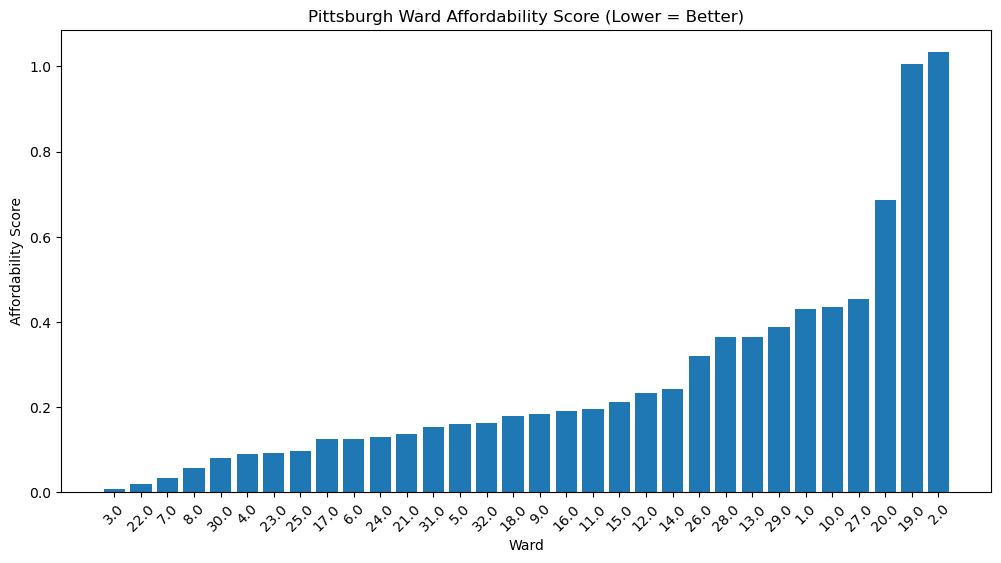

In [12]:
plt.figure(figsize=(12,6))
plt.bar(ward_ranked["ward"], ward_ranked["affordability_score"])
plt.xticks(rotation=45)
plt.title("Pittsburgh Ward Affordability Score (Lower = Better)")
plt.xlabel("Ward")
plt.ylabel("Affordability Score")
plt.show()

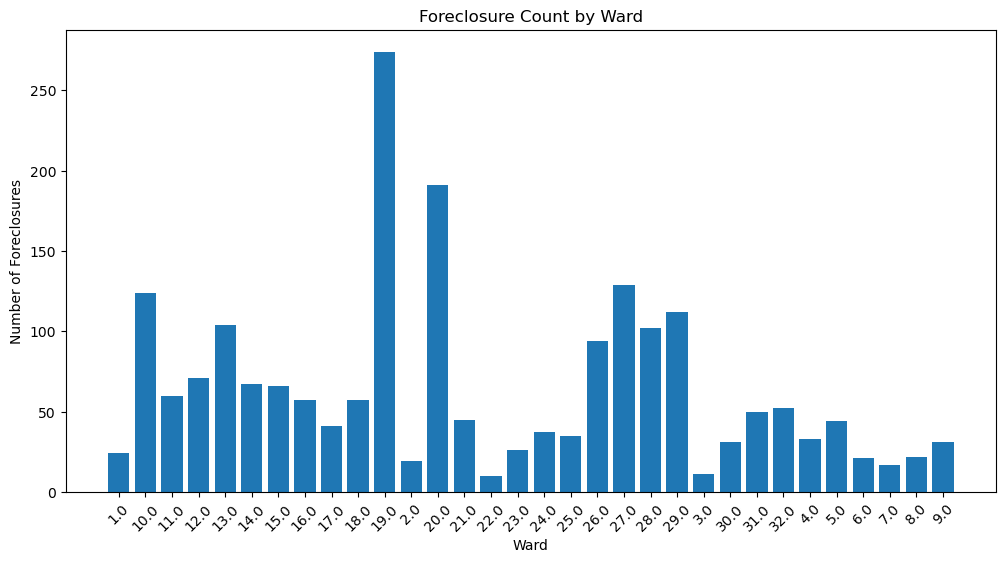

In [13]:
plt.figure(figsize=(12,6))
plt.bar(ward_stats["ward"], ward_stats["foreclosure_count"])
plt.xticks(rotation=45)
plt.title("Foreclosure Count by Ward")
plt.xlabel("Ward")
plt.ylabel("Number of Foreclosures")
plt.show()

# 9. Interpretation of Results

I interpreted lower foreclosure counts and lower foreclosure amounts as indicators of stronger housing stability and affordability.

Wards with low scores represent:

* Fewer housing distress cases
* Lower financial burden from foreclosures

Wards with high scores represent:

* Higher foreclosure activity
* Greater financial stress in housing market
